# Liu2024 S-JEPA Artifact Evaluation (fixed)

This notebook aggregates many artifact folders from the Liu2024 S-JEPA PreLocal runs.

It is designed for large sweeps, including the 200-run preprocessing/hyperparameter sweep. It reads each run's `config.json`, `run_metadata.json`, `global_metrics.json`, `fold_level_results.csv`, `subject_level_summary.csv`, confusion metrics, and optional spatial diagnostics, then produces compact comparison tables.

Long fold/subject tables are **used internally** for diagnostics, but they are not exported unless enabled.

# 1. Setup

In [1]:
from __future__ import annotations

from pathlib import Path
from typing import Any, Iterable
from collections import Counter
import ast
import json
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

pd.set_option("display.max_columns", 240)
pd.set_option("display.width", 260)
pd.set_option("display.max_colwidth", 180)

warnings.filterwarnings("ignore", category=FutureWarning)

# 2. Configuration

In [2]:
# Main artifact folder containing one subfolder per run.
# If this path does not exist, the notebook falls back to /mnt/data so the uploaded single-run example can still be inspected.
WORKING_DIR = Path.cwd().resolve().parent.parent
DEFAULT_ARTIFACT_ROOT = WORKING_DIR / "artifacts/liu2024-source-mat-sjepa-prelocal"
ARTIFACT_ROOT = DEFAULT_ARTIFACT_ROOT

print("Working dir:", WORKING_DIR)
print("Artifact root:", ARTIFACT_ROOT)

CONFIG = {
    # Root containing run folders. If the root itself contains config.json/global_metrics.json,
    # it will be treated as a single-run artifact.
    "artifact_root": str(ARTIFACT_ROOT),

    # None means auto-discover all complete run folders under artifact_root.
    # You can also pass a list of run IDs to force order.
    "run_ids": [
  "20260531_1449_a04eb88a",
  "20260531_1459_b62511d2",
  "20260531_1511_9405f976",
  "20260531_1525_ada6c888",
  "20260531_1538_40e14117",
  "20260531_1550_655d0f4f",
  "20260531_1602_8af2ab67",
  "20260531_1613_59682d08"
    ],

    # Optional filtering after auto-discovery.
    "include_run_id_regex": None,
    "exclude_run_id_regex": r"^_comparison_exports$",

    # Sorting. For sweep order, keep sort_by="config_index_then_time".
    # Other options: "run_id", "metric_desc"
    "sort_by": "config_index_then_time",

    # Primary metric used for leaderboard.
    "primary_metric": "mean_balanced_accuracy",

    # Display/export controls.
    "top_k": 30,
    "top_subject_matrix_runs": 30,
    "make_plots": True,
    "export_tables": True,

    # Keep these False for 200-run sweeps unless you specifically need huge long CSVs.
    "export_subject_long": False,
    "export_fold_long": False,

    # Output folder under artifact_root.
    "export_subdir": "_comparison_exports",

    # Optional screening score for sweep triage. This is not the primary scientific result.
    "compute_screening_score": True,
    "collapse_penalty_weight": 0.03,
    "std_penalty_weight": 0.01,
}

ARTIFACT_ROOT = Path(CONFIG["artifact_root"])
EXPORT_DIR = ARTIFACT_ROOT / CONFIG["export_subdir"]

print("Artifact root:", ARTIFACT_ROOT)
print("Exists:", ARTIFACT_ROOT.exists())

Working dir: /home/vegorov/Repos/eeg_jepa_research
Artifact root: /home/vegorov/Repos/eeg_jepa_research/artifacts/liu2024-source-mat-sjepa-prelocal
Artifact root: /home/vegorov/Repos/eeg_jepa_research/artifacts/liu2024-source-mat-sjepa-prelocal
Exists: True


# 3. Robust file helpers

In [3]:
def read_json(path: Path, default: Any = None) -> Any:
    if not path.exists():
        return default
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)


def read_csv(path: Path, default: Any = None) -> pd.DataFrame | Any:
    if not path.exists():
        return default
    try:
        return pd.read_csv(path)
    except Exception as exc:
        print(f"[WARN] Could not read CSV {path}: {exc}")
        return default


def safe_literal(value: Any) -> Any:
    """Parse JSON/list-like strings from CSV cells when possible."""
    if isinstance(value, str):
        value = value.strip()
        if value.startswith("[") or value.startswith("{"):
            try:
                return ast.literal_eval(value)
            except Exception:
                try:
                    return json.loads(value)
                except Exception:
                    return value
    return value


def json_dumps_short(value: Any) -> str:
    if isinstance(value, (list, dict, tuple)):
        return json.dumps(value, ensure_ascii=False, sort_keys=True)
    return str(value)


def flatten_dict(d: dict[str, Any], parent_key: str = "", sep: str = ".") -> dict[str, Any]:
    out: dict[str, Any] = {}
    for key, value in (d or {}).items():
        new_key = f"{parent_key}{sep}{key}" if parent_key else str(key)
        if isinstance(value, dict):
            out.update(flatten_dict(value, new_key, sep=sep))
        elif isinstance(value, list):
            out[new_key] = json.dumps(value, ensure_ascii=False)
        else:
            out[new_key] = value
    return out


def is_run_dir(path: Path) -> bool:
    return path.is_dir() and (path / "config.json").exists()


def discover_run_dirs(root: Path, run_ids: list[str] | None = None) -> list[Path]:
    """Return run directories. If root itself is a run artifact, return [root]."""
    if is_run_dir(root):
        return [root]

    if run_ids:
        return [root / run_id for run_id in run_ids]

    candidates = [p for p in root.iterdir() if p.is_dir() and is_run_dir(p)]
    include_re = CONFIG.get("include_run_id_regex")
    exclude_re = CONFIG.get("exclude_run_id_regex")
    if include_re:
        candidates = [p for p in candidates if re.search(include_re, p.name)]
    if exclude_re:
        candidates = [p for p in candidates if not re.search(exclude_re, p.name)]
    return sorted(candidates, key=lambda p: p.name)


def mode_value(values: Iterable[Any]) -> Any:
    values = [json_dumps_short(v) for v in values if pd.notna(v)]
    if not values:
        return np.nan
    return Counter(values).most_common(1)[0][0]

# 4. Load run artifacts

In [4]:
def load_single_run(run_dir: Path) -> dict[str, Any]:
    """Load one artifact run. Missing optional files are allowed."""
    config = read_json(run_dir / "config.json", default={})
    meta = read_json(run_dir / "run_metadata.json", default={})
    global_metrics = read_json(run_dir / "global_metrics.json", default={})
    subject_metrics = read_json(run_dir / "subject_metrics.json", default={})

    fold_df = read_csv(run_dir / "fold_level_results.csv", default=pd.DataFrame())
    subject_df = read_csv(run_dir / "subject_level_summary.csv", default=pd.DataFrame())
    global_df = read_csv(run_dir / "global_method_comparison.csv", default=pd.DataFrame())
    confusion_df = read_csv(run_dir / "sjepa_prelocal_confusion_metrics.csv", default=pd.DataFrame())

    spatial_dir = run_dir / "spatial_conv_analysis"
    spatial_diag = read_json(spatial_dir / "diagnostic_summary.json", default={})
    spatial_global_df = read_csv(spatial_dir / "spatial_channel_importance_global.csv", default=pd.DataFrame())
    spatial_long_df = read_csv(spatial_dir / "spatial_channel_importance_long.csv", default=pd.DataFrame())

    run_id = meta.get("run_id") or run_dir.name

    status = "complete" if global_metrics else "partial"
    status_json = read_json(run_dir / "run_status.json", default={})
    if isinstance(status_json, dict):
        status = status_json.get("status", status)

    return {
        "run_id": str(run_id),
        "run_dir": run_dir,
        "status": status,
        "config": config,
        "meta": meta,
        "global_metrics": global_metrics,
        "subject_metrics": subject_metrics,
        "fold_df": fold_df,
        "subject_df": subject_df,
        "global_df": global_df,
        "confusion_df": confusion_df,
        "spatial_diag": spatial_diag,
        "spatial_global_df": spatial_global_df,
        "spatial_long_df": spatial_long_df,
    }


run_dirs = discover_run_dirs(ARTIFACT_ROOT, CONFIG.get("run_ids"))
runs = []
failed_loads = []

for run_dir in run_dirs:
    try:
        run = load_single_run(run_dir)
        if run["status"] == "complete" or run["global_metrics"]:
            runs.append(run)
        else:
            failed_loads.append({"run_id": run_dir.name, "reason": "missing global_metrics.json"})
    except Exception as exc:
        failed_loads.append({"run_id": run_dir.name, "reason": str(exc)})

print(f"Discovered run dirs: {len(run_dirs)}")
print(f"Loaded complete runs: {len(runs)}")
print(f"Skipped/partial runs: {len(failed_loads)}")

if failed_loads:
    display(pd.DataFrame(failed_loads).head(20))

assert runs, "No complete runs found. Check ARTIFACT_ROOT or CONFIG['run_ids']."

Discovered run dirs: 8
Loaded complete runs: 8
Skipped/partial runs: 0


# 5. Derived metrics and compact run summary

In [5]:
PREPROCESSING_KEYS = [
    "source_unit", "final_model_unit",
    "demean_mode", "baseline_window_s", "detrend_mode",
    "eog_correction", "artifact_clip_mode", "artifact_clip_abs_value", "artifact_clip_percentile",
    "reference_mode", "reference_timing",
    "resample", "resample_sfreq", "effective_sfreq",
    "filter_enabled", "filter_low", "filter_high", "filter_method", "filter_phase", "filter_fir_design",
    "filter_l_trans_bandwidth", "filter_h_trans_bandwidth", "filter_iir_params",
    "notch_freqs", "notch_before_bandpass",
    "mi_window_start_s", "target_window_s", "target_window_samples", "effective_window_duration_s",
    "reject_bad_trials", "reject_peak_to_peak_threshold", "reject_abs_threshold",
    "normalization_mode", "normalization_eps",
]

TRAINING_KEYS = [
    "model_name", "pretrained_mode", "strategy", "pretrained_repo_id",
    "optimizer_name", "optimizer", "learning_rate", "weight_decay", "batch_size",
    "n_epochs", "early_stopping_patience", "val_split",
    "gradient_clip_norm",
    "checkpoint_metric", "label_smoothing", "prediction_balance_loss_weight",
    "augmentation_noise_fraction", "augmentation_time_shift_samples", "augmentation_channel_dropout_prob",
    "seed", "cv_random_state", "val_split_random_state", "split_random_state",
]

EVAL_KEYS = [
    "evaluation_mode", "cv_folds", "n_repeats", "test_size", "assert_balanced_folds",
]


RUNTIME_FIRST_KEYS = set(PREPROCESSING_KEYS + EVAL_KEYS + [
    "effective_sfreq", "sfreq", "target_window_samples", "effective_window_duration_s",
    "mi_window_start_s", "seed", "cv_random_state", "val_split_random_state", "split_random_state",
    "learning_rate", "batch_size", "optimizer", "optimizer_name", "weight_decay",
    "checkpoint_metric", "label_smoothing", "prediction_balance_loss_weight",
    "augmentation_noise_fraction", "augmentation_time_shift_samples", "augmentation_channel_dropout_prob",
])


def config_get(run: dict[str, Any], key: str, default: Any = np.nan) -> Any:
    cfg = run["config"] or {}
    meta = run["meta"] or {}
    prep = meta.get("preprocessing_config", {}) or {}

    # For runtime preprocessing/evaluation fields, prefer run_metadata because it records
    # what actually happened after config resolution.
    if key in RUNTIME_FIRST_KEYS:
        if key in prep:
            return prep[key]
        if key in meta:
            return meta[key]
        if key in cfg:
            return cfg[key]
        return default

    # For non-runtime config fields, prefer config because it contains the full planned sweep definition.
    if key in cfg:
        return cfg[key]
    if key in prep:
        return prep[key]
    if key in meta:
        return meta[key]
    return default


def make_band_label(low: Any, high: Any, enabled: Any = True) -> str:
    if enabled is False or str(enabled).lower() == "false":
        return "no_filter"
    try:
        if pd.isna(low) or pd.isna(high):
            return "unknown"
        return f"{float(low):g}-{float(high):g}Hz"
    except Exception:
        return "unknown"


def make_preprocessing_signature(row: dict[str, Any]) -> str:
    parts = [
        f"dm={row.get('demean_mode')}",
        f"det={row.get('detrend_mode')}",
        f"ref={row.get('reference_mode')}@{row.get('reference_timing')}",
        f"fs={row.get('effective_sfreq')}",
        f"band={row.get('filter_band')}",
        f"fmethod={row.get('filter_method')}",
        f"notch={row.get('notch_freqs')}",
        f"eog={row.get('eog_correction')}",
        f"clip={row.get('artifact_clip_mode')}",
        f"norm={row.get('normalization_mode')}",
        f"wstart={row.get('mi_window_start_s')}",
        f"wdur={row.get('effective_window_duration_s')}",
    ]
    return " | ".join(str(p) for p in parts)


def make_training_signature(row: dict[str, Any]) -> str:
    parts = [
        f"{row.get('model_name')}",
        f"{row.get('pretrained_mode')}",
        f"{row.get('strategy')}",
        f"opt={row.get('optimizer_name') or row.get('optimizer')}",
        f"lr={row.get('learning_rate')}",
        f"bs={row.get('batch_size')}",
        f"wd={row.get('weight_decay')}",
        f"val={row.get('val_split')}",
        f"ckpt={row.get('checkpoint_metric')}",
        f"ls={row.get('label_smoothing')}",
        f"balLoss={row.get('prediction_balance_loss_weight')}",
        f"augN={row.get('augmentation_noise_fraction')}",
        f"seed={row.get('seed')}",
    ]
    return " | ".join(str(p) for p in parts)


def parse_confusion_metrics(confusion_df: pd.DataFrame) -> dict[str, Any]:
    out = {}
    if confusion_df is None or confusion_df.empty:
        return out
    row = confusion_df.iloc[0].to_dict()
    cm_value = row.get("confusion_matrix_right_left_order")
    cm = safe_literal(cm_value)
    out["confusion_matrix"] = json.dumps(cm) if isinstance(cm, list) else cm_value
    out["n_predictions"] = row.get("n_predictions", np.nan)
    out["accuracy_from_matrix_percent"] = row.get("accuracy_from_matrix_percent", np.nan)
    try:
        arr = np.array(cm, dtype=float)
        if arr.shape == (2, 2):
            total = arr.sum()
            out["right_recall"] = arr[0, 0] / arr[0].sum() if arr[0].sum() else np.nan
            out["left_recall"] = arr[1, 1] / arr[1].sum() if arr[1].sum() else np.nan
            pred_counts = arr.sum(axis=0)
            out["predicted_right_rate"] = pred_counts[0] / total if total else np.nan
            out["predicted_left_rate"] = pred_counts[1] / total if total else np.nan
            out["prediction_bias_abs"] = abs(pred_counts[0] - pred_counts[1]) / total if total else np.nan
    except Exception:
        pass
    return out


def summarize_folds(fold_df: pd.DataFrame) -> dict[str, Any]:
    out = {}
    if fold_df is None or fold_df.empty:
        return out

    metric_cols = ["accuracy", "balanced_accuracy", "mean_confidence", "mean_normalized_prediction_entropy", "collapse_ratio"]
    for col in metric_cols:
        if col in fold_df.columns:
            s = pd.to_numeric(fold_df[col], errors="coerce")
            out[f"fold_mean_{col}"] = s.mean()
            out[f"fold_std_{col}"] = s.std()
            out[f"fold_median_{col}"] = s.median()
            out[f"fold_q25_{col}"] = s.quantile(0.25)
            out[f"fold_q75_{col}"] = s.quantile(0.75)

    if "balanced_accuracy" in fold_df.columns:
        s = pd.to_numeric(fold_df["balanced_accuracy"], errors="coerce")
        out["fold_pct_above_50"] = (s > 0.50).mean()
        out["fold_pct_above_55"] = (s > 0.55).mean()
        out["fold_pct_above_60"] = (s > 0.60).mean()
        out["fold_pct_above_70"] = (s > 0.70).mean()

    if "collapse_flag" in fold_df.columns:
        out["fold_collapse_rate"] = pd.to_numeric(fold_df["collapse_flag"], errors="coerce").mean()

    for col in ["n_train", "n_test", "train_class_counts", "test_class_counts", "checkpoint_metric"]:
        if col in fold_df.columns:
            out[f"fold_mode_{col}"] = mode_value(fold_df[col])

    for col in [
        "best_epoch", "stopped_epoch", "final_phase_epochs_ran",
        "best_checkpoint_value",
        "best_valid_loss", "history_best_valid_loss",
        "best_valid_balanced_accuracy", "history_best_valid_balanced_accuracy",
        "label_smoothing", "prediction_balance_loss_weight",
    ]:
        if col in fold_df.columns:
            s = pd.to_numeric(fold_df[col], errors="coerce")
            out[f"fold_mean_{col}"] = s.mean()
            out[f"fold_median_{col}"] = s.median()

    return out


def summarize_subjects(subject_df: pd.DataFrame) -> dict[str, Any]:
    out = {}
    if subject_df is None or subject_df.empty:
        return out
    if "mean_balanced_accuracy" in subject_df.columns:
        s = pd.to_numeric(subject_df["mean_balanced_accuracy"], errors="coerce")
        out["subject_mean_of_subject_means"] = s.mean()
        out["subject_std_of_subject_means"] = s.std()
        out["subject_min_mean_balanced_accuracy"] = s.min()
        out["subject_max_mean_balanced_accuracy"] = s.max()
        out["subject_count_above_55"] = int((s > 0.55).sum())
        out["subject_count_above_60"] = int((s > 0.60).sum())
        out["subject_count_above_70"] = int((s > 0.70).sum())
    if "collapse_rate" in subject_df.columns:
        out["subject_mean_collapse_rate"] = pd.to_numeric(subject_df["collapse_rate"], errors="coerce").mean()
    return out


def build_run_summary(runs: list[dict[str, Any]]) -> pd.DataFrame:
    rows = []
    for run in runs:
        cfg = run["config"] or {}
        meta = run["meta"] or {}
        row = {
            "run_id": run["run_id"],
            "run_dir": str(run["run_dir"]),
            "status": run["status"],
            # Prefer runtime metadata for identity fields, but fall back to config.
            "experiment_name": meta.get("experiment_name") or cfg.get("experiment_name"),
            "sweep_group": meta.get("sweep_group") or cfg.get("sweep_group"),
            "config_sweep_index": meta.get("config_sweep_index") if meta.get("config_sweep_index") is not None else cfg.get("config_sweep_index"),
        }

        for k, v in flatten_dict(cfg).items():
            row[f"config.{k}"] = v
        for k, v in flatten_dict(meta).items():
            row[f"meta.{k}"] = v
        for k, v in flatten_dict(run["global_metrics"]).items():
            row[f"global.{k}"] = v
        for k, v in flatten_dict(run["spatial_diag"]).items():
            row[f"spatial.{k}"] = v

        for key in PREPROCESSING_KEYS + TRAINING_KEYS + EVAL_KEYS:
            row[key] = config_get(run, key)

        if pd.isna(row.get("effective_window_duration_s")):
            try:
                row["effective_window_duration_s"] = float(row.get("target_window_samples")) / float(row.get("effective_sfreq"))
            except Exception:
                pass

        row["filter_band"] = make_band_label(row.get("filter_low"), row.get("filter_high"), row.get("filter_enabled"))
        row["preprocessing_signature"] = make_preprocessing_signature(row)
        row["training_signature"] = make_training_signature(row)

        row.update({f"diag.{k}": v for k, v in parse_confusion_metrics(run["confusion_df"]).items()})
        row.update({f"diag.{k}": v for k, v in summarize_folds(run["fold_df"]).items()})
        row.update({f"diag.{k}": v for k, v in summarize_subjects(run["subject_df"]).items()})

        requested = row.get("target_window_s")
        effective = row.get("effective_window_duration_s")
        try:
            row["window_duration_error_s"] = abs(float(requested) - float(effective))
            row["window_duration_mismatch_flag"] = row["window_duration_error_s"] > 0.25
        except Exception:
            row["window_duration_error_s"] = np.nan
            row["window_duration_mismatch_flag"] = False

        for m in ["mean_accuracy", "mean_balanced_accuracy", "std_accuracy", "std_balanced_accuracy", "n_subjects", "n_folds_total"]:
            row[m] = row.get(f"global.{m}", row.get(m, np.nan))

        if pd.isna(row.get("spatial.collapse_rate", np.nan)) and not pd.isna(row.get("diag.fold_collapse_rate", np.nan)):
            row["spatial.collapse_rate"] = row["diag.fold_collapse_rate"]

        if CONFIG.get("compute_screening_score"):
            metric_val = row.get(CONFIG["primary_metric"], row.get(f"global.{CONFIG['primary_metric']}", np.nan))
            std_val = row.get("std_balanced_accuracy", row.get("global.std_balanced_accuracy", np.nan))
            collapse_val = row.get("spatial.collapse_rate", row.get("diag.fold_collapse_rate", np.nan))
            try:
                row["screening_score"] = float(metric_val) - CONFIG["collapse_penalty_weight"] * float(collapse_val) - CONFIG["std_penalty_weight"] * float(std_val)
            except Exception:
                row["screening_score"] = np.nan

        rows.append(row)

    return pd.DataFrame(rows)


run_summary_df = build_run_summary(runs)

if CONFIG["sort_by"] == "config_index_then_time" and "config_sweep_index" in run_summary_df.columns:
    run_summary_df = run_summary_df.sort_values(["config_sweep_index", "run_id"], na_position="last").reset_index(drop=True)
elif CONFIG["sort_by"] == "metric_desc":
    run_summary_df = run_summary_df.sort_values(CONFIG["primary_metric"], ascending=False).reset_index(drop=True)
else:
    run_summary_df = run_summary_df.sort_values("run_id").reset_index(drop=True)

print("run_summary_df:", run_summary_df.shape)
preview_cols = [
    "run_id", "experiment_name", "sweep_group", "config_sweep_index",
    "mean_balanced_accuracy", "std_balanced_accuracy", "spatial.collapse_rate",
    "filter_band", "effective_sfreq", "effective_window_duration_s", "window_duration_mismatch_flag",
    "normalization_mode", "learning_rate", "batch_size", "checkpoint_metric",
    "label_smoothing", "prediction_balance_loss_weight", "evaluation_mode"
]
display(run_summary_df[[c for c in preview_cols if c in run_summary_df.columns]].head(10))

run_summary_df: (8, 326)


,run_id,experiment_name,sweep_group,config_sweep_index,mean_balanced_accuracy,std_balanced_accuracy,spatial.collapse_rate,filter_band,effective_sfreq,effective_window_duration_s,window_duration_mismatch_flag,normalization_mode,learning_rate,batch_size,checkpoint_metric,label_smoothing,prediction_balance_loss_weight,evaluation_mode
0,20260531_1449_a04eb88a,twfb_short153_start1p0_fir_none_bs8_lr0p0004,twfb_short153_timing_sweep,None,0.5035,0.096438,0.624,0.5-40Hz,128.0,1.195312,False,none,0.0004,8,valid_loss,0.0,0.0,stratified_kfold
1,20260531_1459_b62511d2,twfb_short153_start1p5_fir_none_bs8_lr0p0004,twfb_short153_timing_sweep,None,0.5210,0.113728,0.548,0.5-40Hz,128.0,1.195312,False,none,0.0004,8,valid_loss,0.0,0.0,stratified_kfold
2,20260531_1511_9405f976,twfb_short153_start2p0_fir_none_bs8_lr0p0004,twfb_short153_timing_sweep,None,0.5410,0.133488,0.532,0.5-40Hz,128.0,1.195312,False,none,0.0004,8,valid_loss,0.0,0.0,stratified_kfold
3,20260531_1525_ada6c888,twfb_short153_start2p5_fir_none_bs8_lr0p0004,twfb_short153_timing_sweep,None,0.5435,0.139357,0.516,0.5-40Hz,128.0,1.195312,False,none,0.0004,8,valid_loss,0.0,0.0,stratified_kfold
4,20260531_1538_40e14117,twfb_short153_start3p0_fir_none_bs8_lr0p0004,twfb_short153_timing_sweep,None,0.5435,0.128628,0.556,0.5-40Hz,128.0,1.195312,False,none,0.0004,8,valid_loss,0.0,0.0,stratified_kfold
5,20260531_1550_655d0f4f,twfb_short153_start3p5_fir_none_bs8_lr0p0004,twfb_short153_timing_sweep,None,0.5420,0.146154,0.556,0.5-40Hz,128.0,1.195312,False,none,0.0004,8,valid_loss,0.0,0.0,stratified_kfold
6,20260531_1602_8af2ab67,twfb_short153_start4p0_fir_none_bs8_lr0p0004,twfb_short153_timing_sweep,None,0.5295,0.121212,0.580,0.5-40Hz,128.0,1.195312,False,none,0.0004,8,valid_loss,0.0,0.0,stratified_kfold
7,20260531_1613_59682d08,twfb_short153_start4p5_fir_none_bs8_lr0p0004,twfb_short153_timing_sweep,None,0.5250,0.104283,0.632,0.5-40Hz,128.0,1.195312,False,none,0.0004,8,valid_loss,0.0,0.0,stratified_kfold


# 6. Leaderboard and compact config tables

In [6]:
metric = CONFIG["primary_metric"]
if metric not in run_summary_df.columns and f"global.{metric}" in run_summary_df.columns:
    metric = f"global.{metric}"

assert metric in run_summary_df.columns, f"Primary metric column not found: {metric}"

CORE_LEADERBOARD_COLS = [
    "rank",
    "run_id",
    "experiment_name",
    "sweep_group",
    "config_sweep_index",
    metric,
    "mean_accuracy",
    "std_balanced_accuracy",
    "spatial.collapse_rate",
    "diag.prediction_bias_abs",
    "diag.fold_pct_above_55",
    "diag.fold_pct_above_60",
    "screening_score",
    "filter_band",
    "effective_sfreq",
    "target_window_s",
    "target_window_samples",
    "effective_window_duration_s",
    "window_duration_mismatch_flag",
    "window_duration_error_s",
    "mi_window_start_s",
    "demean_mode",
    "detrend_mode",
    "reference_mode",
    "reference_timing",
    "resample",
    "filter_method",
    "notch_freqs",
    "eog_correction",
    "artifact_clip_mode",
    "normalization_mode",
    "learning_rate",
    "batch_size",
    "optimizer_name",
    "optimizer",
    "weight_decay",
    "gradient_clip_norm",
    "checkpoint_metric",
    "label_smoothing",
    "prediction_balance_loss_weight",
    "diag.fold_mode_checkpoint_metric",
    "diag.fold_mean_best_checkpoint_value",
    "diag.fold_mean_best_valid_loss",
    "diag.fold_mean_best_valid_balanced_accuracy",
    "augmentation_noise_fraction",
    "evaluation_mode",
    "cv_folds",
    "n_repeats",
    "test_size",
    "seed",
]

leaderboard_df = run_summary_df.sort_values(metric, ascending=False).reset_index(drop=True).copy()
leaderboard_df.insert(0, "rank", np.arange(1, len(leaderboard_df) + 1))
leaderboard_df = leaderboard_df[[c for c in CORE_LEADERBOARD_COLS if c in leaderboard_df.columns]]

top_k = min(CONFIG["top_k"], len(leaderboard_df))
print(f"Top {top_k} runs by {metric}:")
display(leaderboard_df.head(top_k))

print("Runs flagged for window-duration mismatch:")
mismatch_cols = [c for c in [
    "rank", "run_id", "experiment_name", metric, "target_window_s", "target_window_samples",
    "effective_window_duration_s", "effective_sfreq", "window_duration_error_s"
] if c in leaderboard_df.columns]
display(leaderboard_df[leaderboard_df["window_duration_mismatch_flag"] == True][mismatch_cols].head(30))

Top 8 runs by mean_balanced_accuracy:


,rank,run_id,experiment_name,sweep_group,config_sweep_index,mean_balanced_accuracy,mean_accuracy,std_balanced_accuracy,spatial.collapse_rate,diag.prediction_bias_abs,diag.fold_pct_above_55,diag.fold_pct_above_60,screening_score,filter_band,effective_sfreq,target_window_s,target_window_samples,effective_window_duration_s,window_duration_mismatch_flag,window_duration_error_s,mi_window_start_s,demean_mode,detrend_mode,reference_mode,reference_timing,resample,filter_method,notch_freqs,eog_correction,artifact_clip_mode,normalization_mode,learning_rate,batch_size,optimizer_name,optimizer,weight_decay,gradient_clip_norm,checkpoint_metric,label_smoothing,prediction_balance_loss_weight,augmentation_noise_fraction,evaluation_mode,cv_folds,n_repeats,test_size,seed
0,1,20260531_1525_ada6c888,twfb_short153_start2p5_fir_none_bs8_lr0p0004,twfb_short153_timing_sweep,None,0.5435,0.5435,0.139357,0.516,0.543,0.268,0.268,0.526626,0.5-40Hz,128.0,1.2,153,1.195312,False,0.004687,2.5,none,none,average,before_resample_filter,True,fir,None,none,none,none,0.0004,8,adam,adam,0.0,0,valid_loss,0.0,0.0,0.0,stratified_kfold,5,10,0.4,2026
1,2,20260531_1538_40e14117,twfb_short153_start3p0_fir_none_bs8_lr0p0004,twfb_short153_timing_sweep,None,0.5435,0.5435,0.128628,0.556,0.579,0.260,0.260,0.525534,0.5-40Hz,128.0,1.2,153,1.195312,False,0.004687,3.0,none,none,average,before_resample_filter,True,fir,None,none,none,none,0.0004,8,adam,adam,0.0,0,valid_loss,0.0,0.0,0.0,stratified_kfold,5,10,0.4,2026
2,3,20260531_1550_655d0f4f,twfb_short153_start3p5_fir_none_bs8_lr0p0004,twfb_short153_timing_sweep,None,0.5420,0.5420,0.146154,0.556,0.562,0.272,0.272,0.523858,0.5-40Hz,128.0,1.2,153,1.195312,False,0.004687,3.5,none,none,average,before_resample_filter,True,fir,None,none,none,none,0.0004,8,adam,adam,0.0,0,valid_loss,0.0,0.0,0.0,stratified_kfold,5,10,0.4,2026
3,4,20260531_1511_9405f976,twfb_short153_start2p0_fir_none_bs8_lr0p0004,twfb_short153_timing_sweep,None,0.5410,0.5410,0.133488,0.532,0.506,0.252,0.252,0.523705,0.5-40Hz,128.0,1.2,153,1.195312,False,0.004687,2.0,none,none,average,before_resample_filter,True,fir,None,none,none,none,0.0004,8,adam,adam,0.0,0,valid_loss,0.0,0.0,0.0,stratified_kfold,5,10,0.4,2026
4,5,20260531_1602_8af2ab67,twfb_short153_start4p0_fir_none_bs8_lr0p0004,twfb_short153_timing_sweep,None,0.5295,0.5295,0.121212,0.580,0.607,0.204,0.204,0.510888,0.5-40Hz,128.0,1.2,153,1.195312,False,0.004687,4.0,none,none,average,before_resample_filter,True,fir,None,none,none,none,0.0004,8,adam,adam,0.0,0,valid_loss,0.0,0.0,0.0,stratified_kfold,5,10,0.4,2026
5,6,20260531_1613_59682d08,twfb_short153_start4p5_fir_none_bs8_lr0p0004,twfb_short153_timing_sweep,None,0.5250,0.5250,0.104283,0.632,0.664,0.196,0.196,0.504997,0.5-40Hz,128.0,1.2,153,1.195312,False,0.004687,4.5,none,none,average,before_resample_filter,True,fir,None,none,none,none,0.0004,8,adam,adam,0.0,0,valid_loss,0.0,0.0,0.0,stratified_kfold,5,10,0.4,2026
6,7,20260531_1459_b62511d2,twfb_short153_start1p5_fir_none_bs8_lr0p0004,twfb_short153_timing_sweep,None,0.5210,0.5210,0.113728,0.548,0.580,0.200,0.200,0.503423,0.5-40Hz,128.0,1.2,153,1.195312,False,0.004687,1.5,none,none,average,before_resample_filter,True,fir,None,none,none,none,0.0004,8,adam,adam,0.0,0,valid_loss,0.0,0.0,0.0,stratified_kfold,5,10,0.4,2026
7,8,20260531_1449_a04eb88a,twfb_short153_start1p0_fir_none_bs8_lr0p0004,twfb_short153_timing_sweep,None,0.5035,0.5035,0.096438,0.624,0.623,0.132,0.132,0.483816,0.5-40Hz,128.0,1.2,153,1.195312,False,0.004687,1.0,none,none,average,before_resample_filter,True,fir,None,none,none,none,0.0004,8,adam,adam,0.0,0,valid_loss,0.0,0.0,0.0,stratified_kfold,5,10,0.4,2026


Runs flagged for window-duration mismatch:


,rank,run_id,experiment_name,mean_balanced_accuracy,target_window_s,target_window_samples,effective_window_duration_s,effective_sfreq,window_duration_error_s


# 7. Group summaries and hyperparameter effects

In [7]:
def _make_groupable_value(x):
    """Convert list/dict/NaN values into stable readable groupby keys."""
    if isinstance(x, (list, tuple, set)):
        if len(x) == 0:
            return "none"
        return ",".join(str(v) for v in x)

    if isinstance(x, dict):
        if len(x) == 0:
            return "none"
        return json.dumps(x, sort_keys=True)

    if isinstance(x, np.ndarray):
        if x.size == 0:
            return "none"
        return ",".join(str(v) for v in x.tolist())

    try:
        if pd.isna(x):
            return "none"
    except Exception:
        pass

    return x


def summarize_by(
    df: pd.DataFrame,
    group_cols: list[str],
    metric_col: str,
    min_runs: int = 1,
) -> pd.DataFrame:
    """Summarize a metric by one or more config/preprocessing columns.

    This version is safe for sweep config columns that may contain lists/dicts,
    such as notch_freqs, baseline_window_s, or filter_iir_params.
    """
    group_cols = [c for c in group_cols if c in df.columns]

    if not group_cols or metric_col not in df.columns:
        return pd.DataFrame()

    work = df.copy()
    work[metric_col] = pd.to_numeric(work[metric_col], errors="coerce")
    work = work[work[metric_col].notna()].copy()

    if work.empty:
        return pd.DataFrame()

    for col in group_cols:
        work[col] = work[col].map(_make_groupable_value)

    agg_dict = {
        "n_runs": (metric_col, "count"),
        "mean_metric": (metric_col, "mean"),
        "median_metric": (metric_col, "median"),
        "max_metric": (metric_col, "max"),
        "min_metric": (metric_col, "min"),
        "std_metric": (metric_col, "std"),
    }

    if "spatial.collapse_rate" in work.columns:
        work["spatial.collapse_rate"] = pd.to_numeric(work["spatial.collapse_rate"], errors="coerce")
        agg_dict["mean_collapse"] = ("spatial.collapse_rate", "mean")

    if "std_balanced_accuracy" in work.columns:
        work["std_balanced_accuracy"] = pd.to_numeric(work["std_balanced_accuracy"], errors="coerce")
        agg_dict["mean_std_balacc"] = ("std_balanced_accuracy", "mean")

    if "window_duration_mismatch_flag" in work.columns:
        work["window_duration_mismatch_flag"] = work["window_duration_mismatch_flag"].astype(float)
        agg_dict["window_mismatch_rate"] = ("window_duration_mismatch_flag", "mean")

    if "n_folds_total" in work.columns:
        work["n_folds_total"] = pd.to_numeric(work["n_folds_total"], errors="coerce")
        agg_dict["mean_n_folds"] = ("n_folds_total", "mean")

    out = (
        work.groupby(group_cols, dropna=False)
        .agg(**agg_dict)
        .reset_index()
    )

    out = out[out["n_runs"] >= min_runs].copy()

    if out.empty:
        return out

    out["mean_metric_pct"] = out["mean_metric"] * 100
    out["median_metric_pct"] = out["median_metric"] * 100
    out["max_metric_pct"] = out["max_metric"] * 100
    out["min_metric_pct"] = out["min_metric"] * 100

    sort_cols = ["mean_metric", "max_metric", "n_runs"]
    return out.sort_values(sort_cols, ascending=[False, False, False])


group_summary_df = summarize_by(run_summary_df, ["sweep_group"], metric)
eval_summary_df = summarize_by(run_summary_df, ["evaluation_mode"], metric)
band_summary_df = summarize_by(run_summary_df, ["filter_band"], metric)
fs_summary_df = summarize_by(run_summary_df, ["effective_sfreq"], metric)

print("By sweep group:")
display(group_summary_df)

print("By evaluation mode:")
display(eval_summary_df)

print("By filter band:")
display(band_summary_df)

print("By effective sampling rate:")
display(fs_summary_df)


effect_params = [
    "sweep_group",
    "evaluation_mode",
    "effective_sfreq",
    "filter_band",
    "filter_method",
    "filter_phase",
    "filter_fir_design",
    "filter_l_trans_bandwidth",
    "filter_h_trans_bandwidth",
    "demean_mode",
    "detrend_mode",
    "reference_mode",
    "reference_timing",
    "notch_freqs",
    "notch_before_bandpass",
    "eog_correction",
    "artifact_clip_mode",
    "normalization_mode",
    "mi_window_start_s",
    "effective_window_duration_s",
    "window_duration_mismatch_flag",
    "learning_rate",
    "batch_size",
    "optimizer_name",
    "optimizer",
    "weight_decay",
    "val_split",
    "early_stopping_patience",
    "gradient_clip_norm",
    "checkpoint_metric",
    "label_smoothing",
    "prediction_balance_loss_weight",
    "augmentation_noise_fraction",
    "augmentation_time_shift_samples",
    "augmentation_channel_dropout_prob",
]

effect_rows = []

for param in effect_params:
    if param not in run_summary_df.columns:
        continue

    tmp = summarize_by(run_summary_df, [param], metric)

    if tmp.empty:
        continue

    tmp.insert(0, "parameter", param)
    tmp = tmp.rename(columns={param: "value"})
    effect_rows.append(tmp)

hyperparameter_effects_df = (
    pd.concat(effect_rows, ignore_index=True)
    if effect_rows
    else pd.DataFrame()
)

print("Hyperparameter/preprocessing effect summaries:")
display(hyperparameter_effects_df.head(120))


By sweep group:


,sweep_group,n_runs,mean_metric,median_metric,max_metric,min_metric,std_metric,mean_collapse,mean_std_balacc,window_mismatch_rate,mean_n_folds,mean_metric_pct,median_metric_pct,max_metric_pct,min_metric_pct
0,twfb_short153_timing_sweep,8,0.531125,0.53525,0.5435,0.5035,0.014282,0.568,0.122911,0.0,250.0,53.1125,53.525,54.35,50.35


By evaluation mode:


,evaluation_mode,n_runs,mean_metric,median_metric,max_metric,min_metric,std_metric,mean_collapse,mean_std_balacc,window_mismatch_rate,mean_n_folds,mean_metric_pct,median_metric_pct,max_metric_pct,min_metric_pct
0,stratified_kfold,8,0.531125,0.53525,0.5435,0.5035,0.014282,0.568,0.122911,0.0,250.0,53.1125,53.525,54.35,50.35


By filter band:


,filter_band,n_runs,mean_metric,median_metric,max_metric,min_metric,std_metric,mean_collapse,mean_std_balacc,window_mismatch_rate,mean_n_folds,mean_metric_pct,median_metric_pct,max_metric_pct,min_metric_pct
0,0.5-40Hz,8,0.531125,0.53525,0.5435,0.5035,0.014282,0.568,0.122911,0.0,250.0,53.1125,53.525,54.35,50.35


By effective sampling rate:


,effective_sfreq,n_runs,mean_metric,median_metric,max_metric,min_metric,std_metric,mean_collapse,mean_std_balacc,window_mismatch_rate,mean_n_folds,mean_metric_pct,median_metric_pct,max_metric_pct,min_metric_pct
0,128.0,8,0.531125,0.53525,0.5435,0.5035,0.014282,0.568,0.122911,0.0,250.0,53.1125,53.525,54.35,50.35


Hyperparameter/preprocessing effect summaries:


,parameter,value,n_runs,mean_metric,median_metric,max_metric,min_metric,std_metric,mean_collapse,mean_std_balacc,window_mismatch_rate,mean_n_folds,mean_metric_pct,median_metric_pct,max_metric_pct,min_metric_pct
0,sweep_group,twfb_short153_timing_sweep,8,0.531125,0.53525,0.5435,0.5035,0.014282,0.568,0.122911,0.0,250.0,53.1125,53.525,54.35,50.35
1,evaluation_mode,stratified_kfold,8,0.531125,0.53525,0.5435,0.5035,0.014282,0.568,0.122911,0.0,250.0,53.1125,53.525,54.35,50.35
2,effective_sfreq,128.0,8,0.531125,0.53525,0.5435,0.5035,0.014282,0.568,0.122911,0.0,250.0,53.1125,53.525,54.35,50.35
3,filter_band,0.5-40Hz,8,0.531125,0.53525,0.5435,0.5035,0.014282,0.568,0.122911,0.0,250.0,53.1125,53.525,54.35,50.35
4,filter_method,fir,8,0.531125,0.53525,0.5435,0.5035,0.014282,0.568,0.122911,0.0,250.0,53.1125,53.525,54.35,50.35
5,filter_phase,zero,8,0.531125,0.53525,0.5435,0.5035,0.014282,0.568,0.122911,0.0,250.0,53.1125,53.525,54.35,50.35
6,filter_fir_design,firwin,8,0.531125,0.53525,0.5435,0.5035,0.014282,0.568,0.122911,0.0,250.0,53.1125,53.525,54.35,50.35
7,filter_l_trans_bandwidth,auto,8,0.531125,0.53525,0.5435,0.5035,0.014282,0.568,0.122911,0.0,250.0,53.1125,53.525,54.35,50.35
8,filter_h_trans_bandwidth,auto,8,0.531125,0.53525,0.5435,0.5035,0.014282,0.568,0.122911,0.0,250.0,53.1125,53.525,54.35,50.35
9,demean_mode,none,8,0.531125,0.53525,0.5435,0.5035,0.014282,0.568,0.122911,0.0,250.0,53.1125,53.525,54.35,50.35


# 8. Fold-level diagnostics without exporting giant fold tables

In [8]:
fold_diag_cols = [
    "run_id", "experiment_name", "sweep_group", metric,
    "diag.fold_mean_accuracy", "diag.fold_std_accuracy", "diag.fold_median_accuracy",
    "diag.fold_q25_accuracy", "diag.fold_q75_accuracy",
    "diag.fold_pct_above_50", "diag.fold_pct_above_55", "diag.fold_pct_above_60", "diag.fold_pct_above_70",
    "diag.fold_collapse_rate",
    "diag.fold_mode_checkpoint_metric",
    "diag.fold_mean_best_epoch", "diag.fold_median_best_epoch",
    "diag.fold_mean_stopped_epoch", "diag.fold_median_stopped_epoch",
    "diag.fold_mean_best_checkpoint_value", "diag.fold_median_best_checkpoint_value",
    "diag.fold_mean_best_valid_loss", "diag.fold_median_best_valid_loss",
    "diag.fold_mean_best_valid_balanced_accuracy", "diag.fold_median_best_valid_balanced_accuracy",
    "diag.fold_mean_label_smoothing", "diag.fold_mean_prediction_balance_loss_weight",
    "diag.fold_mode_n_train", "diag.fold_mode_n_test",
    "diag.fold_mode_train_class_counts", "diag.fold_mode_test_class_counts",
    "diag.fold_mean_mean_confidence", "diag.fold_mean_mean_normalized_prediction_entropy",
]
fold_diagnostics_df = run_summary_df[[c for c in fold_diag_cols if c in run_summary_df.columns]].copy()

display(fold_diagnostics_df.sort_values(metric, ascending=False).head(CONFIG["top_k"]))

,run_id,experiment_name,sweep_group,mean_balanced_accuracy,diag.fold_mean_accuracy,diag.fold_std_accuracy,diag.fold_median_accuracy,diag.fold_q25_accuracy,diag.fold_q75_accuracy,diag.fold_pct_above_50,diag.fold_pct_above_55,diag.fold_pct_above_60,diag.fold_pct_above_70,diag.fold_collapse_rate,diag.fold_mean_best_epoch,diag.fold_median_best_epoch,diag.fold_mean_stopped_epoch,diag.fold_median_stopped_epoch,diag.fold_mode_n_train,diag.fold_mode_n_test,diag.fold_mode_train_class_counts,diag.fold_mode_test_class_counts,diag.fold_mean_mean_confidence,diag.fold_mean_mean_normalized_prediction_entropy
3,20260531_1525_ada6c888,twfb_short153_start2p5_fir_none_bs8_lr0p0004,twfb_short153_timing_sweep,0.5435,0.5435,0.139636,0.5,0.5,0.62500,0.268,0.268,0.268,0.160,0.516,274.476,33.0,323.328,79.0,32,8,"[16, 16]","[4, 4]",0.562755,0.955401
4,20260531_1538_40e14117,twfb_short153_start3p0_fir_none_bs8_lr0p0004,twfb_short153_timing_sweep,0.5435,0.5435,0.128886,0.5,0.5,0.62500,0.260,0.260,0.260,0.140,0.556,201.192,19.5,250.008,59.0,32,8,"[16, 16]","[4, 4]",0.548303,0.974047
5,20260531_1550_655d0f4f,twfb_short153_start3p5_fir_none_bs8_lr0p0004,twfb_short153_timing_sweep,0.5420,0.5420,0.146447,0.5,0.5,0.62500,0.272,0.272,0.272,0.156,0.556,236.244,4.0,285.388,52.5,32,8,"[16, 16]","[4, 4]",0.553931,0.967199
2,20260531_1511_9405f976,twfb_short153_start2p0_fir_none_bs8_lr0p0004,twfb_short153_timing_sweep,0.5410,0.5410,0.133756,0.5,0.5,0.59375,0.252,0.252,0.252,0.148,0.532,289.368,31.5,337.632,73.0,32,8,"[16, 16]","[4, 4]",0.562495,0.959560
6,20260531_1602_8af2ab67,twfb_short153_start4p0_fir_none_bs8_lr0p0004,twfb_short153_timing_sweep,0.5295,0.5295,0.121455,0.5,0.5,0.50000,0.204,0.204,0.204,0.100,0.580,179.896,4.5,229.112,53.0,32,8,"[16, 16]","[4, 4]",0.543650,0.975522
7,20260531_1613_59682d08,twfb_short153_start4p5_fir_none_bs8_lr0p0004,twfb_short153_timing_sweep,0.5250,0.5250,0.104492,0.5,0.5,0.50000,0.196,0.196,0.196,0.100,0.632,176.048,1.5,225.112,51.0,32,8,"[16, 16]","[4, 4]",0.545789,0.972879
1,20260531_1459_b62511d2,twfb_short153_start1p5_fir_none_bs8_lr0p0004,twfb_short153_timing_sweep,0.5210,0.5210,0.113956,0.5,0.5,0.50000,0.200,0.200,0.200,0.080,0.548,195.796,11.0,244.052,60.0,32,8,"[16, 16]","[4, 4]",0.545407,0.976969
0,20260531_1449_a04eb88a,twfb_short153_start1p0_fir_none_bs8_lr0p0004,twfb_short153_timing_sweep,0.5035,0.5035,0.096631,0.5,0.5,0.50000,0.132,0.132,0.132,0.052,0.624,179.904,4.0,228.644,51.0,32,8,"[16, 16]","[4, 4]",0.538365,0.981391


# 9. Subject-level diagnostics and subject stability

In [9]:
def build_subject_long(runs: list[dict[str, Any]]) -> pd.DataFrame:
    rows = []
    for run in runs:
        sdf = run["subject_df"]
        if sdf is None or sdf.empty:
            sm = run.get("subject_metrics", {}) or {}
            for subject_id, metrics in sm.items():
                row = {"run_id": run["run_id"], "subject_id": subject_id}
                if isinstance(metrics, dict):
                    row.update(metrics)
                rows.append(row)
            continue

        tmp = sdf.copy()
        tmp.insert(0, "run_id", run["run_id"])
        tmp.insert(1, "experiment_name", (run["config"] or {}).get("experiment_name") or (run["meta"] or {}).get("experiment_name"))
        tmp.insert(2, "sweep_group", (run["config"] or {}).get("sweep_group") or (run["meta"] or {}).get("sweep_group"))
        rows.extend(tmp.to_dict("records"))

    if not rows:
        return pd.DataFrame()

    df = pd.DataFrame(rows)
    if "subject_id" in df.columns:
        df["subject_id"] = df["subject_id"].astype(str)
    return df


subject_long_df = build_subject_long(runs)

if subject_long_df.empty:
    print("No subject-level data found.")
    subject_stability_df = pd.DataFrame()
    subject_matrix_df = pd.DataFrame()
else:
    subj_metric = "mean_balanced_accuracy" if "mean_balanced_accuracy" in subject_long_df.columns else "mean_accuracy"
    subject_long_df[subj_metric] = pd.to_numeric(subject_long_df[subj_metric], errors="coerce")

    subject_stability_df = (
        subject_long_df.groupby("subject_id", dropna=False)
        .agg(
            n_runs=(subj_metric, "count"),
            mean_across_runs=(subj_metric, "mean"),
            std_across_runs=(subj_metric, "std"),
            min_across_runs=(subj_metric, "min"),
            max_across_runs=(subj_metric, "max"),
        )
        .reset_index()
        .sort_values("mean_across_runs", ascending=False)
    )

    print("Most consistently high subjects across loaded runs:")
    display(subject_stability_df.head(15))

    print("Most consistently low subjects across loaded runs:")
    display(subject_stability_df.tail(15))

    top_run_ids = leaderboard_df.head(CONFIG["top_subject_matrix_runs"])["run_id"].tolist()
    top_subject_df = subject_long_df[subject_long_df["run_id"].isin(top_run_ids)].copy()
    subject_matrix_df = top_subject_df.pivot_table(index="subject_id", columns="run_id", values=subj_metric, aggfunc="mean")
    subject_matrix_df = subject_matrix_df[[run_id for run_id in top_run_ids if run_id in subject_matrix_df.columns]]
    subject_matrix_df = subject_matrix_df.reindex(sorted(subject_matrix_df.index, key=lambda x: int(x) if str(x).isdigit() else str(x)))

    print("Subject x top-runs matrix:")
    display(subject_matrix_df.head(50))

Most consistently high subjects across loaded runs:


,subject_id,n_runs,mean_across_runs,std_across_runs,min_across_runs,max_across_runs
14,22,8,0.693750,0.146232,0.500,0.900
31,38,8,0.684375,0.061146,0.600,0.750
9,18,8,0.659375,0.155229,0.450,0.825
27,34,8,0.646875,0.145429,0.500,0.875
48,8,8,0.634375,0.090571,0.500,0.750
34,40,8,0.590625,0.086538,0.500,0.725
4,13,8,0.590625,0.095373,0.500,0.750
28,35,8,0.587500,0.042258,0.500,0.650
47,7,8,0.559375,0.054996,0.475,0.650
38,44,8,0.559375,0.069356,0.500,0.700


Most consistently low subjects across loaded runs:


,subject_id,n_runs,mean_across_runs,std_across_runs,min_across_runs,max_across_runs
46,6,8,0.493750,0.051322,0.375,0.550
15,23,8,0.493750,0.029124,0.450,0.525
45,50,8,0.493750,0.022160,0.450,0.525
2,11,8,0.493750,0.054691,0.425,0.575
32,39,8,0.490625,0.035197,0.425,0.525
44,5,8,0.490625,0.071885,0.400,0.600
16,24,8,0.487500,0.035355,0.400,0.500
37,43,8,0.487500,0.026726,0.425,0.500
43,49,8,0.487500,0.023146,0.450,0.500
24,31,8,0.484375,0.048065,0.425,0.550


Subject x top-runs matrix:


run_id,20260531_1525_ada6c888,20260531_1538_40e14117,20260531_1550_655d0f4f,20260531_1511_9405f976,20260531_1602_8af2ab67,20260531_1613_59682d08,20260531_1459_b62511d2,20260531_1449_a04eb88a
subject_id,,,,,,,,
1,0.450,0.575,0.650,0.425,0.625,0.500,0.525,0.400
2,0.450,0.475,0.650,0.500,0.500,0.475,0.500,0.500
3,0.450,0.425,0.500,0.450,0.475,0.500,0.425,0.525
4,0.575,0.550,0.525,0.475,0.450,0.500,0.550,0.525
5,0.475,0.400,0.500,0.400,0.600,0.475,0.575,0.500
6,0.375,0.500,0.500,0.500,0.500,0.550,0.525,0.500
7,0.600,0.550,0.525,0.550,0.475,0.600,0.650,0.525
8,0.725,0.550,0.725,0.625,0.750,0.600,0.600,0.500
9,0.450,0.575,0.475,0.500,0.625,0.525,0.575,0.500


# 10. Plots

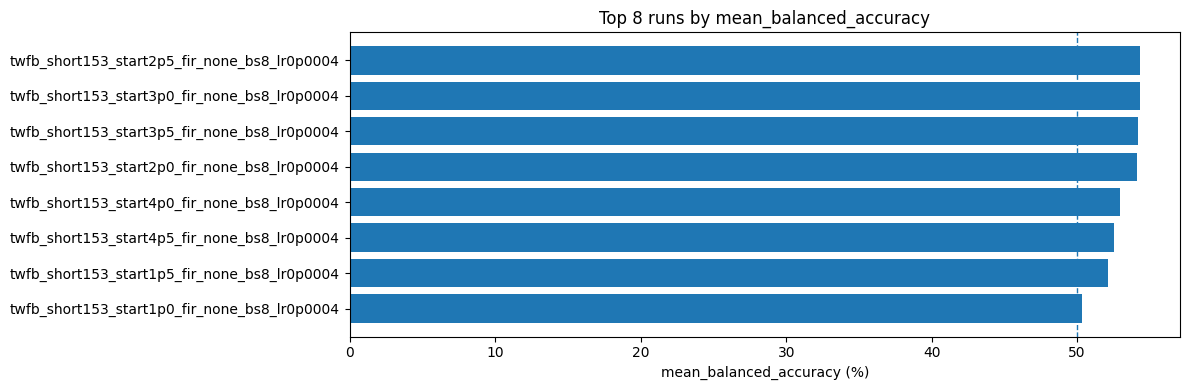

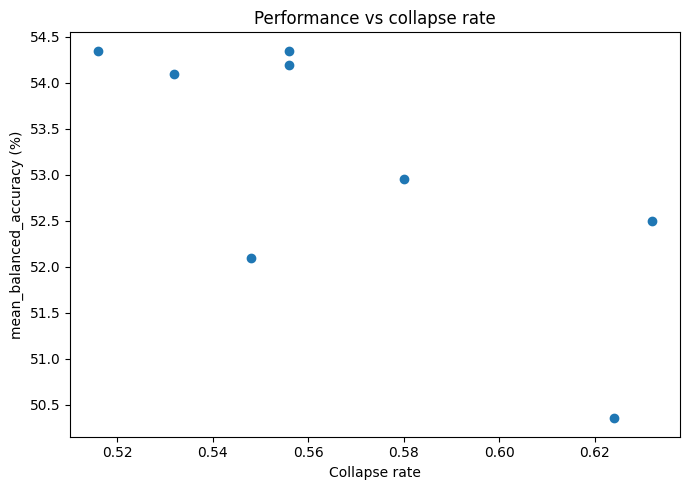

/tmp/ipykernel_4095263/1656921348.py:35: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(values, labels=[str(g) for g in groups], vert=True)


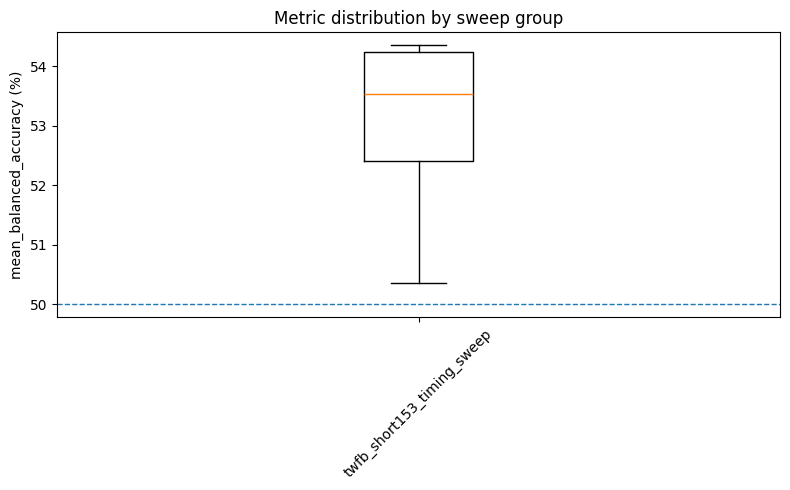

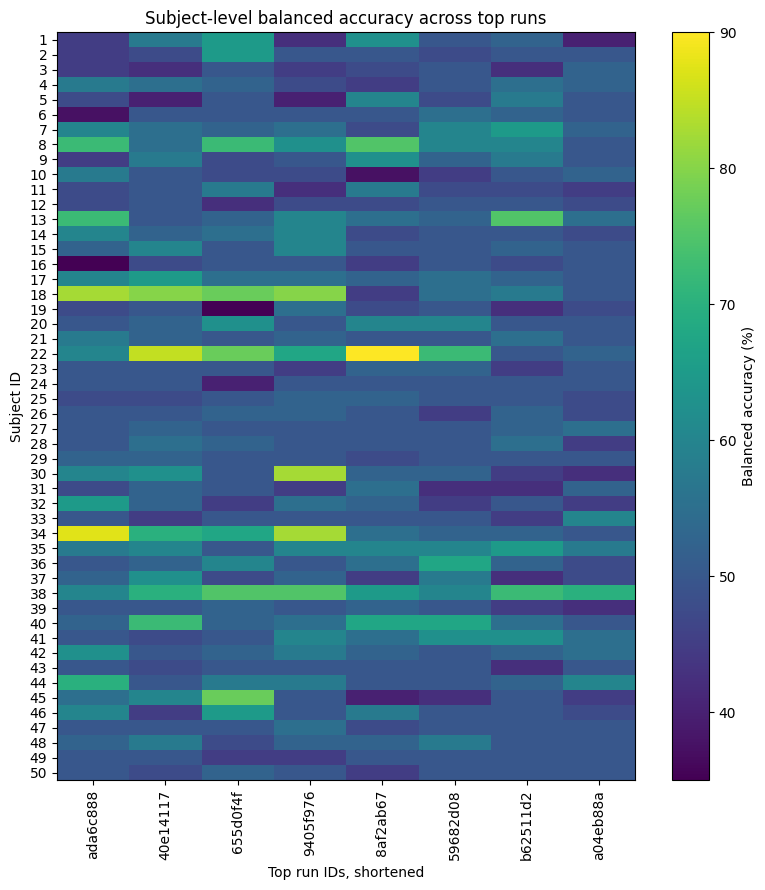

Saved plots to: /home/vegorov/Repos/eeg_jepa_research/artifacts/liu2024-source-mat-sjepa-prelocal/_comparison_exports/plots


In [10]:
if CONFIG["make_plots"]:
    plot_dir = EXPORT_DIR / "plots"
    plot_dir.mkdir(parents=True, exist_ok=True)

    top_plot = leaderboard_df.head(min(CONFIG["top_k"], 30)).copy()
    if not top_plot.empty:
        fig, ax = plt.subplots(figsize=(12, max(4, 0.35 * len(top_plot))))
        labels = top_plot["experiment_name"].fillna(top_plot["run_id"]).astype(str)
        ax.barh(range(len(top_plot)), top_plot[metric] * 100)
        ax.set_yticks(range(len(top_plot)))
        ax.set_yticklabels(labels)
        ax.invert_yaxis()
        ax.axvline(50, linestyle="--", linewidth=1)
        ax.set_xlabel(f"{metric} (%)")
        ax.set_title(f"Top {len(top_plot)} runs by {metric}")
        fig.tight_layout()
        fig.savefig(plot_dir / "top_runs_leaderboard.png", dpi=180)
        plt.show()

    if "spatial.collapse_rate" in run_summary_df.columns:
        fig, ax = plt.subplots(figsize=(7, 5))
        ax.scatter(run_summary_df["spatial.collapse_rate"], run_summary_df[metric] * 100)
        ax.set_xlabel("Collapse rate")
        ax.set_ylabel(f"{metric} (%)")
        ax.set_title("Performance vs collapse rate")
        fig.tight_layout()
        fig.savefig(plot_dir / "performance_vs_collapse.png", dpi=180)
        plt.show()

    if "sweep_group" in run_summary_df.columns and run_summary_df["sweep_group"].notna().any():
        groups = [g for g, _ in run_summary_df.groupby("sweep_group", dropna=False)]
        values = [run_summary_df.loc[run_summary_df["sweep_group"] == g, metric].dropna() * 100 for g in groups]
        if values:
            fig, ax = plt.subplots(figsize=(max(8, 0.8 * len(groups)), 5))
            ax.boxplot(values, labels=[str(g) for g in groups], vert=True)
            ax.axhline(50, linestyle="--", linewidth=1)
            ax.set_ylabel(f"{metric} (%)")
            ax.set_title("Metric distribution by sweep group")
            ax.tick_params(axis="x", rotation=45)
            fig.tight_layout()
            fig.savefig(plot_dir / "metric_by_sweep_group.png", dpi=180)
            plt.show()

    if 'subject_matrix_df' in globals() and not subject_matrix_df.empty:
        mat = subject_matrix_df.astype(float).to_numpy() * 100
        fig, ax = plt.subplots(figsize=(max(8, 0.35 * mat.shape[1]), max(6, 0.18 * mat.shape[0])))
        im = ax.imshow(mat, aspect="auto")
        ax.set_yticks(range(len(subject_matrix_df.index)))
        ax.set_yticklabels(subject_matrix_df.index)
        ax.set_xticks(range(len(subject_matrix_df.columns)))
        ax.set_xticklabels([str(c)[-8:] for c in subject_matrix_df.columns], rotation=90)
        ax.set_xlabel("Top run IDs, shortened")
        ax.set_ylabel("Subject ID")
        ax.set_title("Subject-level balanced accuracy across top runs")
        fig.colorbar(im, ax=ax, label="Balanced accuracy (%)")
        fig.tight_layout()
        fig.savefig(plot_dir / "subject_by_top_run_matrix.png", dpi=180)
        plt.show()

    print("Saved plots to:", plot_dir)
else:
    print("Plotting disabled.")

# 11. Export comparison tables

In [11]:
if CONFIG["export_tables"]:
    EXPORT_DIR.mkdir(parents=True, exist_ok=True)

    leaderboard_df.to_csv(EXPORT_DIR / "leaderboard.csv", index=False)
    run_summary_df.to_csv(EXPORT_DIR / "run_summary_full.csv", index=False)
    group_summary_df.to_csv(EXPORT_DIR / "group_summary.csv", index=False)
    eval_summary_df.to_csv(EXPORT_DIR / "evaluation_protocol_summary.csv", index=False)
    band_summary_df.to_csv(EXPORT_DIR / "filter_band_summary.csv", index=False)
    fs_summary_df.to_csv(EXPORT_DIR / "sampling_rate_summary.csv", index=False)
    hyperparameter_effects_df.to_csv(EXPORT_DIR / "hyperparameter_effects_summary.csv", index=False)
    fold_diagnostics_df.to_csv(EXPORT_DIR / "fold_diagnostics_by_run.csv", index=False)

    if 'subject_stability_df' in globals() and not subject_stability_df.empty:
        subject_stability_df.to_csv(EXPORT_DIR / "subject_stability_across_runs.csv", index=False)
    if 'subject_matrix_df' in globals() and not subject_matrix_df.empty:
        subject_matrix_df.to_csv(EXPORT_DIR / "subject_by_top_runs_matrix.csv")

    if CONFIG["export_subject_long"] and 'subject_long_df' in globals() and not subject_long_df.empty:
        subject_long_df.to_csv(EXPORT_DIR / "subject_summary_long.csv", index=False)

    if CONFIG["export_fold_long"]:
        fold_rows = []
        for run in runs:
            fdf = run["fold_df"]
            if fdf is not None and not fdf.empty:
                tmp = fdf.copy()
                tmp.insert(0, "run_id", run["run_id"])
                tmp.insert(1, "experiment_name", (run["config"] or {}).get("experiment_name") or (run["meta"] or {}).get("experiment_name"))
                tmp.insert(2, "sweep_group", (run["config"] or {}).get("sweep_group") or (run["meta"] or {}).get("sweep_group"))
                fold_rows.append(tmp)
        if fold_rows:
            pd.concat(fold_rows, ignore_index=True).to_csv(EXPORT_DIR / "fold_summary_long.csv", index=False)

    top = leaderboard_df.iloc[0].to_dict()
    summary_lines = [
        "# Artifact comparison summary",
        "",
        f"Loaded runs: {len(runs)}",
        "",
        f"Primary metric: `{metric}`",
        "",
        "Best run:",
        f"- Run ID: `{top.get('run_id')}`",
        f"- Experiment: `{top.get('experiment_name')}`",
        f"- Metric: {top.get(metric)}",
        f"- Collapse rate: {top.get('spatial.collapse_rate')}",
        f"- Filter band: {top.get('filter_band')}",
        f"- Effective sfreq: {top.get('effective_sfreq')}",
        f"- Effective window duration: {top.get('effective_window_duration_s')}",
        f"- Window duration mismatch flag: {top.get('window_duration_mismatch_flag')}",
        f"- Checkpoint metric: {top.get('checkpoint_metric')}",
        f"- Label smoothing: {top.get('label_smoothing')}",
        f"- Prediction balance loss weight: {top.get('prediction_balance_loss_weight')}",
        "",
        "Generated tables:",
        "- `leaderboard.csv`",
        "- `run_summary_full.csv`",
        "- `group_summary.csv`",
        "- `hyperparameter_effects_summary.csv`",
        "- `fold_diagnostics_by_run.csv`",
        "- `subject_stability_across_runs.csv`",
        "- `subject_by_top_runs_matrix.csv`",
    ]
    (EXPORT_DIR / "comparison_summary.md").write_text("\n".join(summary_lines), encoding="utf-8")

    print("Exported comparison tables to:", EXPORT_DIR)
else:
    print("Export disabled.")

Exported comparison tables to: /home/vegorov/Repos/eeg_jepa_research/artifacts/liu2024-source-mat-sjepa-prelocal/_comparison_exports


# 12. Notes for interpreting the outputs

Recommended workflow for the 200-run sweep:

1. Start with `leaderboard.csv`.
2. Check `window_duration_mismatch_flag` before treating a run as comparable.  
   A no-resample run with `target_window_samples=537` at 500 Hz is only about 1.074 s, not 4.2 s.
3. Use `group_summary.csv` and `hyperparameter_effects_summary.csv` to see broad preprocessing effects.
4. Use `fold_diagnostics_by_run.csv` to check whether a run is high-performing because of actual learning or because of collapse/class bias.
5. Use `subject_stability_across_runs.csv` to identify subjects that are consistently decodable or consistently near chance.
6. Keep long fold/subject exports disabled unless you need to debug one run in detail.